## QGAN

In this notebook, we train a PyTorch-based Quantum Generative Adversarial Network with a Qiskit quantum generator to prepare a quantum state close to a given probability distribution.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import Adam
from qiskit import QuantumCircuit
from qiskit.circuit.library import n_local
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.primitives import QMLSampler
from qiskit_machine_learning.utils import algorithm_globals
from scipy.stats import entropy

We first generate training data taken from a simple probability distribution

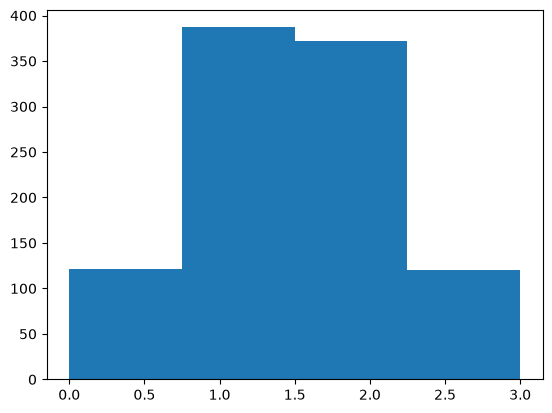

In [2]:
np.random.seed(2020)
N = 1000

real_data = np.random.binomial(3,0.5,N)
plt.hist(real_data, bins = 4);

Now, we define the quantum generator and classical discriminator, train them with the real data, and represent the learned distribution in a histogram.

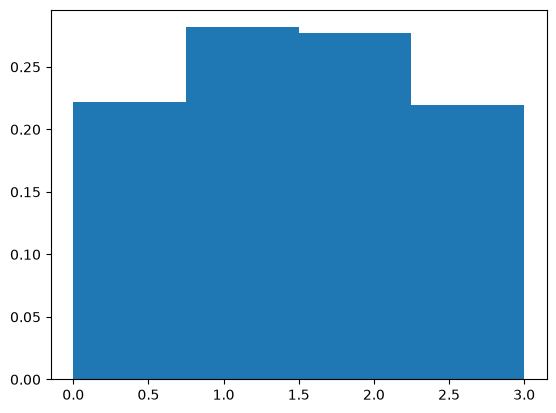

In [3]:
n = 2
num_epochs = 100
batch_size = 100
num_values = 2**n

algorithm_globals.random_seed = 2020
torch.manual_seed(2020)
rng = np.random.default_rng(2020)

target_probabilities = np.bincount(real_data, minlength=num_values) / len(real_data)
samples = torch.arange(num_values, dtype=torch.float32).reshape(-1, 1)

generator_circuit = QuantumCircuit(n)
generator_circuit.h(range(n))
generator_circuit.compose(
    n_local(n, rotation_blocks="ry", entanglement_blocks="cz", entanglement="circular", reps=1),
    inplace=True,
)

training_qnn = SamplerQNN(
    circuit=generator_circuit,
    sampler=QMLSampler(shots=batch_size),
    input_params=[],
    weight_params=generator_circuit.parameters,
    sparse=False,
)
generator = TorchConnector(
    training_qnn,
    initial_weights=algorithm_globals.random.random(generator_circuit.num_parameters) * 2e-2,
)

evaluation_qnn = SamplerQNN(
    circuit=generator_circuit,
    sampler=QMLSampler(shots=None),
    input_params=[],
    weight_params=generator_circuit.parameters,
    sparse=False,
)
evaluation_generator = TorchConnector(
    evaluation_qnn, initial_weights=np.zeros(generator_circuit.num_parameters)
)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1, 50, bias=False)
        self.linear2 = nn.Linear(50, 20, bias=False)
        self.linear3 = nn.Linear(20, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()
        with torch.no_grad():
            self.linear1.weight.copy_(torch.tensor((algorithm_globals.random.random(tuple(self.linear1.weight.shape)) * 2 - 1) * 0.7, dtype=torch.float32))
            self.linear2.weight.copy_(torch.tensor((algorithm_globals.random.random(tuple(self.linear2.weight.shape)) * 2 - 1) * 0.7, dtype=torch.float32))
            self.linear3.weight.copy_(torch.tensor((algorithm_globals.random.random(tuple(self.linear3.weight.shape)) * 2 - 1) * 0.2, dtype=torch.float32))

    def forward(self, values):
        values = self.leaky_relu(self.linear1(values))
        values = self.leaky_relu(self.linear2(values))
        return self.sigmoid(self.linear3(values))

def adversarial_loss(prediction, target, weights):
    prediction = torch.clamp(prediction, 1e-4, 1 - 1e-4)
    return -torch.sum(weights * (target * torch.log(prediction) + (1 - target) * torch.log(1 - prediction)))

discriminator = Discriminator()
generator_optimizer = Adam(generator.parameters(), lr=1e-3, betas=(0.7, 0.99), eps=1e-6, amsgrad=True)
discriminator_optimizer = Adam(discriminator.parameters(), lr=1e-3, betas=(0.7, 0.99), eps=1e-6, amsgrad=True)

g_loss = []
d_loss = []
rel_entr = []

for _ in range(num_epochs):
    rng.shuffle(real_data)

    for index in range(0, len(real_data) - batch_size + 1, batch_size):
        real_batch = torch.tensor(real_data[index:index + batch_size], dtype=torch.float32).reshape(-1, 1)

        discriminator_optimizer.zero_grad()
        generated_distribution = generator(torch.tensor([])).reshape(-1, 1)
        real_loss = adversarial_loss(
            discriminator(real_batch), torch.ones(batch_size, 1), torch.full((batch_size, 1), 1 / batch_size)
        )
        fake_loss = adversarial_loss(
            discriminator(samples), torch.zeros(num_values, 1), generated_distribution.detach()
        )
        discriminator_loss = (real_loss + fake_loss) / 2
        discriminator_loss.backward()
        discriminator_optimizer.step()

        generator_optimizer.zero_grad()
        generated_distribution = generator(torch.tensor([])).reshape(-1, 1)
        generator_loss = adversarial_loss(
            discriminator(samples), torch.ones(num_values, 1), generated_distribution
        )
        generator_loss.backward()
        generator_optimizer.step()

    g_loss.append(generator_loss.item())
    d_loss.append(discriminator_loss.item())
    with torch.no_grad():
        evaluation_generator.weight.copy_(generator.weight)
        prob_g = evaluation_generator(torch.tensor([])).numpy()
    rel_entr.append(entropy(np.maximum(prob_g, 1e-8), target_probabilities))

with torch.no_grad():
    evaluation_generator.weight.copy_(generator.weight)
    prob_g = evaluation_generator(torch.tensor([])).numpy()

plt.hist(range(num_values), weights=prob_g, bins=num_values);

We show the evolution of the loss function of both the generator and the discriminator

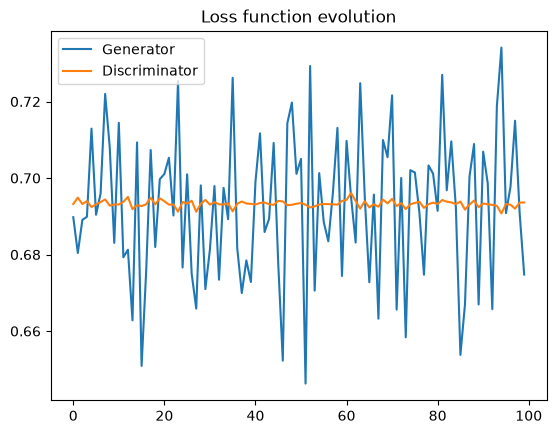

In [4]:
plt.title("Loss function evolution")
plt.plot(range(num_epochs), g_loss, label='Generator')
plt.plot(range(num_epochs), d_loss, label='Discriminator')
plt.legend()
plt.show()

And, also, the evolution of the relative entropy during the training.

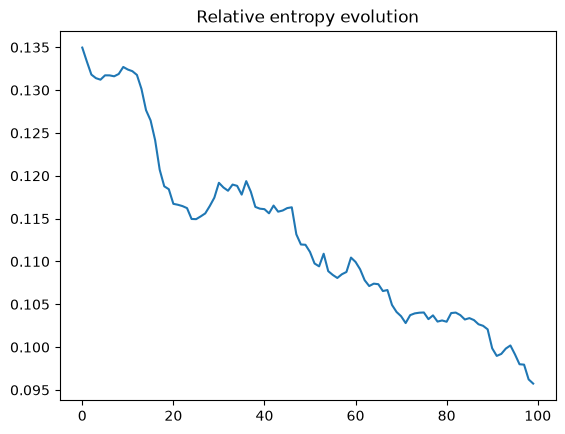

In [5]:
plt.title('Relative entropy evolution')
plt.plot(rel_entr)
plt.show()

In [6]:
from importlib.metadata import version

print("Qiskit:", version("qiskit"))
print("Qiskit Machine Learning:", version("qiskit-machine-learning"))
print("PyTorch:", version("torch"))

Qiskit: 2.5.2
Qiskit Machine Learning: 0.9.1
PyTorch: 2.13.0
